In [1]:
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  import seaborn as sns
  from sklearn.model_selection import train_test_split
  from sklearn.preprocessing import StandardScaler
  from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
  from xgboost import XGBClassifier
  import joblib



/Users/erdemcetin/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


ModuleNotFoundError: No module named 'xgboost'

In [24]:
pip install xgboost       

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.5 MB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 49.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.6.0 requires daal==2021.4.0, which is not installed.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.24.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv('creditcard.csv')  

In [3]:
print(f"Shape: {df.shape}")

Shape: (284807, 31)


In [4]:
print(f"\nFraud distribution:\n{df['Class'].value_counts()}")


Fraud distribution:
0    284315
1       492
Name: Class, dtype: int64


In [5]:
print(f"\nFraud rate: {df['Class'].mean()*100:.3f}%")    


Fraud rate: 0.173%


In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
fraud_df = df[df['Class'] == 1]                                                                                                                                          
print(f"Toplam fraud: {len(fraud_df)}")                                                                                                                                  
fraud_df.head(10)   

Toplam fraud: 492


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
6331,7526.0,0.008430,4.137837,-6.240697,6.675732,0.768307,-3.353060,-1.631735,0.154612,-2.795892,...,0.364514,-0.608057,-0.539528,0.128940,1.488481,0.507963,0.735822,0.513574,1.00,1
6334,7535.0,0.026779,4.132464,-6.560600,6.348557,1.329666,-2.513479,-1.689102,0.303253,-3.139409,...,0.370509,-0.576752,-0.669605,-0.759908,1.605056,0.540675,0.737040,0.496699,1.00,1
6336,7543.0,0.329594,3.712889,-5.775935,6.078266,1.667359,-2.420168,-0.812891,0.133080,-2.214311,...,0.156617,-0.652450,-0.551572,-0.716522,1.415717,0.555265,0.530507,0.404474,1.00,1
6338,7551.0,0.316459,3.809076,-5.615159,6.047445,1.554026,-2.651353,-0.746579,0.055586,-2.678679,...,0.208828,-0.511747,-0.583813,-0.219845,1.474753,0.491192,0.518868,0.402528,1.00,1
6427,7610.0,0.725646,2.300894,-5.329976,4.007683,-1.730411,-1.732193,-3.968593,1.063728,-0.486097,...,0.589669,0.109541,0.601045,-0.364700,-1.843078,0.351909,0.594550,0.099372,1.00,1


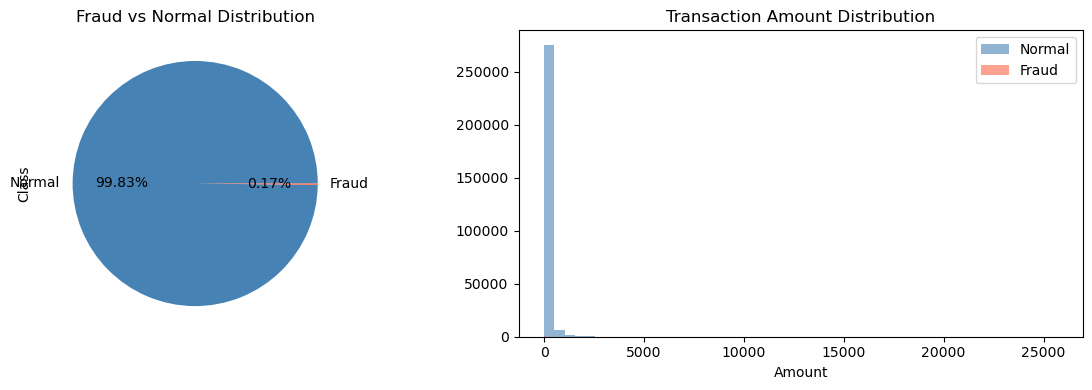

In [8]:
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))                                                                                                                          
                  
  df['Class'].value_counts().plot(kind='pie', ax=axes[0],                                                                                                                  
      labels=['Normal', 'Fraud'], autopct='%1.2f%%', colors=['steelblue', 'tomato'])
  axes[0].set_title('Fraud vs Normal Distribution')                                                                                                                        
                                                                                                                                                                           
  axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, label='Normal', color='steelblue')                                                                        
  axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6, label='Fraud', color='tomato')                                                                            
  axes[1].set_title('Transaction Amount Distribution')                                                                                                                     
  axes[1].set_xlabel('Amount')
  axes[1].legend()                                                                                                                                                         
                  
  plt.tight_layout()
  plt.show()

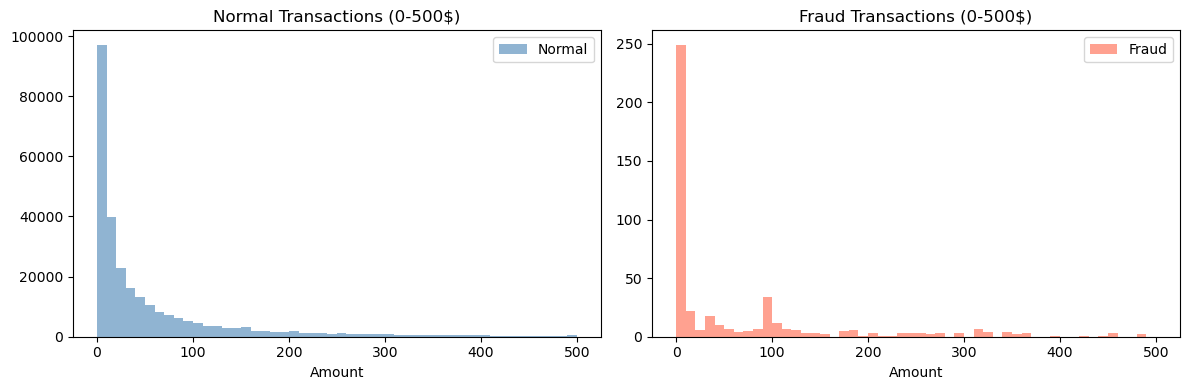

In [9]:
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))                                                                                                                          
   
  axes[0].hist(df[df['Class']==0]['Amount'], bins=50, range=(0, 500), alpha=0.6, label='Normal', color='steelblue')                                                        
  axes[0].set_title('Normal Transactions (0-500$)')
  axes[0].set_xlabel('Amount')                                                                                                                                             
  axes[0].legend()     

  axes[1].hist(df[df['Class']==1]['Amount'], bins=50, range=(0, 500), alpha=0.6, label='Fraud', color='tomato')                                                            
  axes[1].set_title('Fraud Transactions (0-500$)')
  axes[1].set_xlabel('Amount')                                                                                                                                             
  axes[1].legend()                                                                                                                                                         
   
  plt.tight_layout()                                                                                                                                                       
  plt.show()      

In [10]:
  print(f"Normal max amount: ${df[df['Class']==0]['Amount'].max():.2f}")                                                                                                   
  print(f"Fraud max amount: ${df[df['Class']==1]['Amount'].max():.2f}")                                                                                                    
  print(f"Normal mean amount: ${df[df['Class']==0]['Amount'].mean():.2f}")
  print(f"Fraud mean amount: ${df[df['Class']==1]['Amount'].mean():.2f}")  

Normal max amount: $25691.16
Fraud max amount: $2125.87
Normal mean amount: $88.29
Fraud mean amount: $122.21


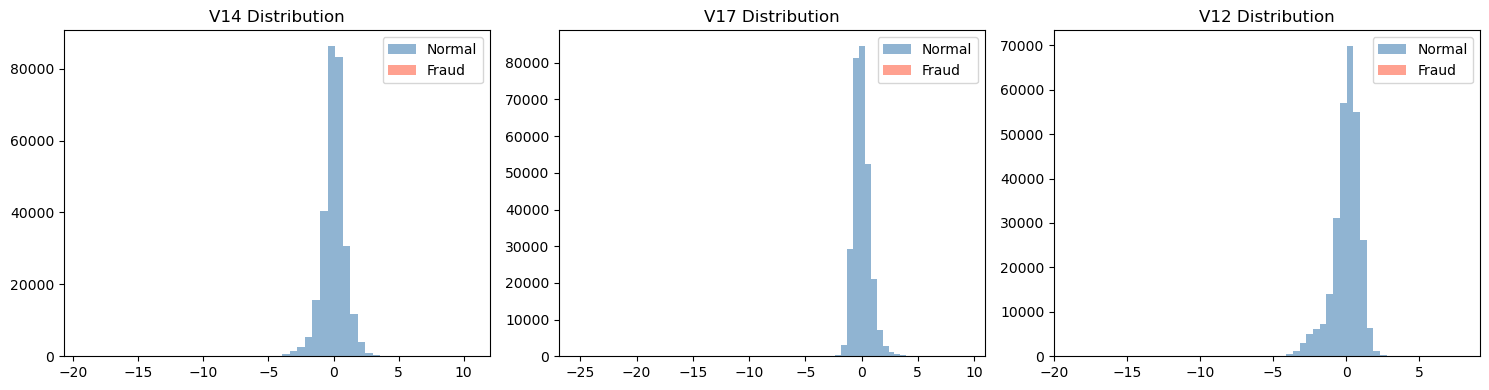

In [11]:
  fig, axes = plt.subplots(1, 3, figsize=(15, 4))                                                                                                                          
                                                                                                                                                                           
  for i, feature in enumerate(['V14', 'V17', 'V12']):                                                                                                                      
      axes[i].hist(df[df['Class']==0][feature], bins=50, alpha=0.6, label='Normal', color='steelblue')                                                                     
      axes[i].hist(df[df['Class']==1][feature], bins=50, alpha=0.6, label='Fraud', color='tomato')                                                                         
      axes[i].set_title(f'{feature} Distribution')
      axes[i].legend()                                                                                                                                                     
                                                                                                                                                                           
  plt.tight_layout()
  plt.show()   

In [12]:
  correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)                                                                                       
  print(correlations.head(10))  

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [13]:
  from sklearn.preprocessing import StandardScaler                                                                                                                         
   
  scaler = StandardScaler()                                                                                                                                                
                  
  df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])                                                                                                               
  df['Time_scaled'] = scaler.fit_transform(df[['Time']])
                                                                                                                                                                           
  df = df.drop(['Amount', 'Time'], axis=1)
                                                                                                                                                                           
  print("Feature engineering done ✅")                                                                                                                                     
  print(df.shape)


Feature engineering done ✅
(284807, 31)


In [14]:
df.columns.tolist()  

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Class',
 'Amount_scaled',
 'Time_scaled']

In [15]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [16]:
print(f"Amount_scaled: min={df['Amount_scaled'].min():.2f}, max={df['Amount_scaled'].max():.2f}")                                                                        
print(f"Time_scaled: min={df['Time_scaled'].min():.2f}, max={df['Time_scaled'].max():.2f}")  

Amount_scaled: min=-0.35, max=102.36
Time_scaled: min=-2.00, max=1.64


In [17]:
  X = df.drop('Class', axis=1)                                                                                                                                             
  y = df['Class']
                                                                                                                                                                           
  X_train, X_test, y_train, y_test = train_test_split(                                                                                                                     
      X, y, test_size=0.2, random_state=42, stratify=y
  )                                                                                                                                                                        
                  
  print(f"X_train: {X_train.shape}")                                                                                                                                       
  print(f"X_test: {X_test.shape}")
  print(f"Train fraud count: {y_train.sum()}")                                                                                                                             
  print(f"Test fraud count: {y_test.sum()}")

X_train: (227845, 30)
X_test: (56962, 30)
Train fraud count: 394
Test fraud count: 98


In [25]:
  # Base Model (Without SMOTE)                                                                                                                                             
  # Before applying SMOTE, we train a baseline XGBoost model on the imbalanced dataset.
  # This gives us a reference point to compare against the SMOTE-balanced model.                                                                                           
  # The model is expected to miss most fraud cases due to the class imbalance.
                                                                                                                                                                           
  from xgboost import XGBClassifier
  from sklearn.metrics import classification_report                                                                                                                        
                  
  base_model = XGBClassifier(random_state=42, eval_metric='logloss')                                                                                                       
  base_model.fit(X_train, y_train)
                                                                                                                                                                           
  y_pred = base_model.predict(X_test)
  print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.92      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [26]:
  # Results (Without SMOTE):                                                                                                                                               
  # Precision: 0.92 - 92% of predicted frauds were actually fraud
  # Recall: 0.81 - model caught 81% of real frauds, missed 19%                                                                                                             
  # F1: 0.86      
  # This is our baseline. We will try to improve recall with SMOTE.    

In [28]:
pip install imbalanced-learn   

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 14.7 MB/s eta 0:00:00
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0
Note: you may need to restart the kernel to use updated packages.


In [29]:
                                                                                                                                                                           
  # SMOTE Application                                                                                                                                                      
  # We oversample the minority class (fraud) to balance the training data.                                                                                                 
  # This does NOT train the model yet — it only prepares the balanced dataset. 
  # Before: 394 fraud | After: 227,451 fraud (synthetic samples added)  

  from imblearn.over_sampling import SMOTE                                                                                                                                 
                                                                                                                                                                           
  smote = SMOTE(random_state=42)
  X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
                                                                                                                                                                           
  print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
  print(f"After SMOTE: {y_train_resampled.value_counts().to_dict()}") 

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [30]:
  # Train XGBoost on SMOTE-balanced data                                                                                                                                   
  # Comparing results with baseline to see if recall improves on fraud detection                                                                                           
                                                                                                                                                                           
  model = XGBClassifier(random_state=42, eval_metric='logloss')                                                                                                            
  model.fit(X_train_resampled, y_train_resampled)                                                                                                                          
                                                                                                                                                                           
  y_pred_smote = model.predict(X_test)
  print(classification_report(y_test, y_pred_smote, target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [31]:
  # Results Comparison (Base vs SMOTE)                                                                                                                                     
  # Base model (no SMOTE): Precision=0.92, Recall=0.81, F1=0.86
  # SMOTE model:           Precision=0.73, Recall=0.89, F1=0.80                                                                                                            
  #                                                                                                                                                                        
  # SMOTE improved recall (catches more fraud) but reduced precision (more false alarms)                                                                                   
  # Trade-off: missing real fraud is worse than false alarms in banking                                                                                                    
  # Next step: threshold tuning to find the optimal balance      

Best threshold: 0.9845
Best F1: 0.8603


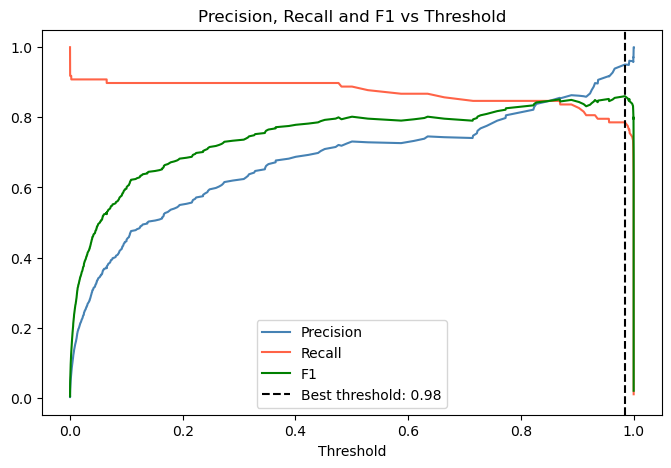

In [32]:
  # Precision-Recall Curve & Optimal Threshold                                                                                                                             
  # We plot the PR curve to find the threshold that maximizes F1 score                                                                                                     
  # This helps us balance precision and recall optimally                                                                                                                   
                  
  from sklearn.metrics import precision_recall_curve                                                                                                                       
  import numpy as np
                                                                                                                                                                           
  y_scores = model.predict_proba(X_test)[:, 1]                                                                                                                             
  precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)
                                                                                                                                                                           
  f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
  best_threshold = thresholds[np.argmax(f1_scores)]
                                                                                                                                                                           
  print(f"Best threshold: {best_threshold:.4f}")
  print(f"Best F1: {np.max(f1_scores):.4f}")                                                                                                                               
                                                                                                                                                                           
  plt.figure(figsize=(8, 5))
  plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')                                                                                              
  plt.plot(thresholds, recalls[:-1], label='Recall', color='tomato')                                                                                                       
  plt.plot(thresholds, f1_scores[:-1], label='F1', color='green')
  plt.axvline(best_threshold, linestyle='--', color='black', label=f'Best threshold: {best_threshold:.2f}')                                                                
  plt.xlabel('Threshold')                                                                                                                                                  
  plt.title('Precision, Recall and F1 vs Threshold')                                                                                                                       
  plt.legend()                                                                                                                                                             
  plt.show()     

In [ ]:
  # Problem: SMOTE resulted in an unusually high optimal threshold (0.98)                                                                                                  
  # This means the model only flags fraud when it is 98% confident — too strict                                                                                            
  # Root cause: SMOTE generated too many synthetic fraud samples (394 -> 227,451)                                                                                          
  # causing the model to become overly conservative on the real test set                                                                                                   
  #                                                                                                                                                                        
  # Solution: Try class_weight instead of SMOTE                                                                                                                            
  # Instead of generating synthetic samples, we tell XGBoost to penalize                                                                                                   
  # missed fraud cases more heavily during training                                                                                                                        
  # scale_pos_weight = normal_count / fraud_count = 227451 / 394 = ~577                                                                                                    
                                                                            

In [33]:
  # Class Weight Model                                                                                                                                                     
  # Instead of SMOTE, we use scale_pos_weight to handle class imbalance
  # XGBoost penalizes missed fraud cases 577x more than missed normal cases                                                                                                
                                                                                                                                                                           
  model_cw = XGBClassifier(                                                                                                                                                
      random_state=42,                                                                                                                                                     
      eval_metric='logloss',                                                                                                                                               
      scale_pos_weight=227451/394
  )                                                                                                                                                                        
  model_cw.fit(X_train, y_train)
                                                                                                                                                                           
  y_pred_cw = model_cw.predict(X_test)
  print(classification_report(y_test, y_pred_cw, target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [34]:
  # Final Model Comparison:                                                                                                                                                
  # Base (no balancing):  Precision=0.92, Recall=0.81, F1=0.86                                                                                                             
  # SMOTE:                Precision=0.73, Recall=0.89, F1=0.80 — too many false alarms                                                                                     
  # Class Weight:         Precision=0.88, Recall=0.85, F1=0.86 — best balance                                                                                              
  #                                                                                                                                                                        
  # Winner: Class Weight model (model_cw)                                                                                                                                  
  # Reason: Higher recall than base model, much better precision than SMOTE                                                                                                
  # No threshold issues — works at default 0.5                                                                                                                             
  # This model will be saved as model.pkl for production use                                                                                                               
                                                                 

ROC-AUC Score: 0.9652


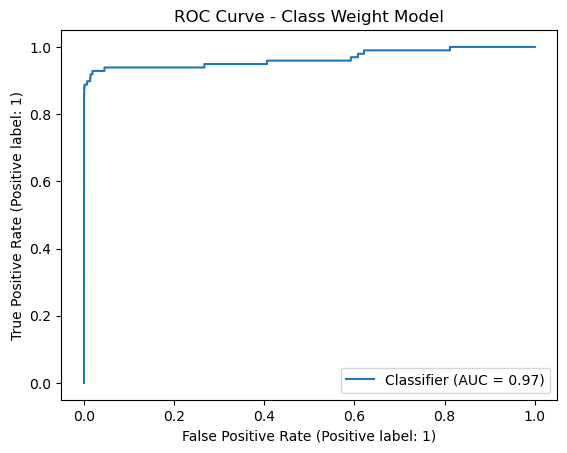

In [35]:
  # ROC-AUC Score                                                                                                                                                          
  # Measures the model's ability to distinguish fraud from normal transactions                                                                                             
  # Score ranges from 0.5 (random) to 1.0 (perfect)                                                                                                                        
                                                                                                                                                                           
  from sklearn.metrics import roc_auc_score, RocCurveDisplay                                                                                                               
                                                                                                                                                                           
  y_scores_cw = model_cw.predict_proba(X_test)[:, 1]                                                                                                                       
  auc_score = roc_auc_score(y_test, y_scores_cw)
  print(f"ROC-AUC Score: {auc_score:.4f}")                                                                                                                                 
                  
  RocCurveDisplay.from_predictions(y_test, y_scores_cw)                                                                                                                    
  plt.title('ROC Curve - Class Weight Model')
  plt.show()       

In [ ]:
  # Decision: Upgrade to Stacking Ensemble                                                                                                                                 
  # XGBoost alone achieved: Precision=0.88, Recall=0.85, F1=0.86, ROC-AUC=0.9652                                                                                           
  # Research shows stacking (XGBoost + LightGBM + CatBoost) can reach ROC-AUC 0.98+                                                                                        
  # Next step: Train all three base models, then combine with Logistic Regression meta-model        

In [36]:
pip install lightgbm catboost    

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 10.1 MB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 9.7 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for catboost (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [98 lines of output]
      /private/var/folders/mc/k138j8ks00n3_0pmny68zkgh0000gn/T/pip-build-env-d_ft1tqr/overlay/lib/python3.9/site-packages/setuptools/_vendor/wheel/bdist_wheel.py:4: FutureWarning: The 'wheel' package is no longer the canonical location of the 'bdist_wheel' command, and will be removed in a future release. Please update to setuptools v70.1 or later which contains an integrated version of this command.
        warn(
      running bdist_wheel
   

Note: you may need to restart the kernel to use updated packages.


In [38]:
  # Stacking Ensemble - XGBoost + LightGBM                                                                                                                                 
  # Meta-model: Logistic Regression combines both models' predictions for final decision                                                                                   
                                                                                                                                                                           
  from lightgbm import LGBMClassifier                                                                                                                                      
  from sklearn.linear_model import LogisticRegression                                                                                                                      
  from sklearn.ensemble import StackingClassifier                                                                                                                          
   
  base_models = [                                                                                                                                                          
      ('xgb', XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=227451/394)),
      ('lgbm', LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1))                                                                                       
  ]
                                                                                                                                                                           
  meta_model = LogisticRegression()                                                                                                                                        
   
  stacking_model = StackingClassifier(                                                                                                                                     
      estimators=base_models,
      final_estimator=meta_model,
      cv=5
  )                                                                                                                                                                        
   
  stacking_model.fit(X_train, y_train)                                                                                                                                     
  print("Stacking model trained ✅")


Stacking model trained ✅


In [39]:
  # Stacking Model Evaluation                                                                                                                                              
  # Comparing stacking ensemble results against single XGBoost model                                                                                                       
                                                                                                                                                                           
  y_pred_stack = stacking_model.predict(X_test)                                                                                                                            
  print(classification_report(y_test, y_pred_stack, target_names=['Normal', 'Fraud']))
                                                                                                                                                                           
  y_scores_stack = stacking_model.predict_proba(X_test)[:, 1]
  auc_stack = roc_auc_score(y_test, y_scores_stack)                                                                                                                        
  print(f"ROC-AUC: {auc_stack:.4f}")       

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.90      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9736


In [40]:
                                                                                                                                                                           
  # Final Model Selection: XGBoost with class_weight                                                                                                                       
  # Reason: Higher recall (0.85 vs 0.80) — catching more fraud is priority in banking                                                                                      
  # Stacking improved ROC-AUC and precision but sacrificed recall                                                                                                          
  # model_cw is saved as the production model                                                                                                                              
                                                                                                                                                                           
  import joblib                                                                                                                                                            
                                                                                                                                                                           
  joblib.dump(model_cw, 'model.pkl')                                                                                                                                       
  print("Model saved as model.pkl ✅")
                                           

Model saved as model.pkl ✅


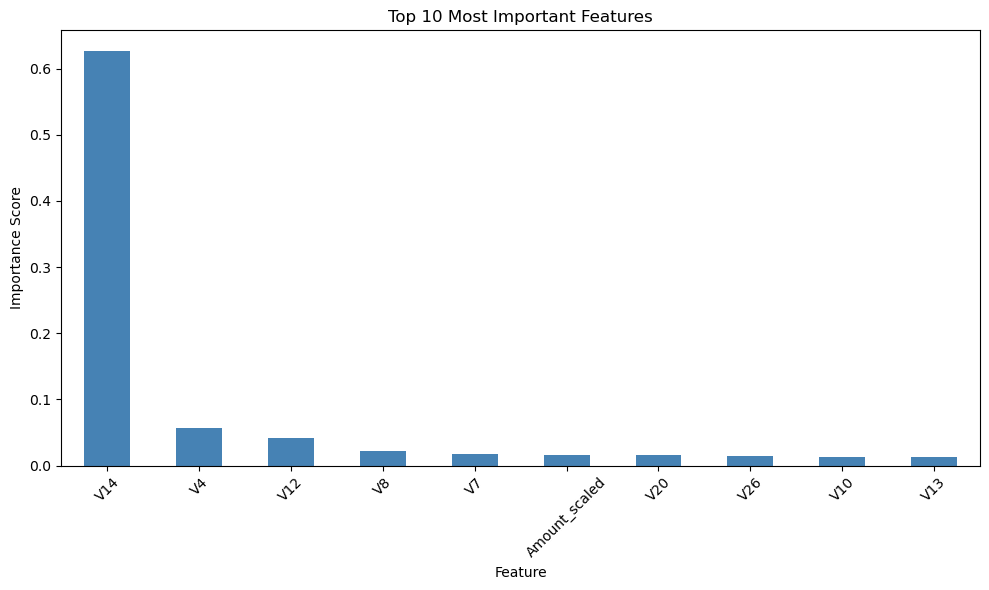

V14              0.626459
V4               0.057104
V12              0.041454
V8               0.021751
V7               0.017657
Amount_scaled    0.016332
V20              0.015917
V26              0.014048
V10              0.013529
V13              0.012994
dtype: float32


In [41]:
  # Feature Importance
  # Shows which features contributed most to fraud detection                                                                                                               
  # Helps understand what drives the model's decisions
                                                                                                                                                                           
  feature_importance = pd.Series(
      model_cw.feature_importances_,                                                                                                                                       
      index=X_train.columns
  ).sort_values(ascending=False).head(10)

  plt.figure(figsize=(10, 6))                                                                                                                                              
  feature_importance.plot(kind='bar', color='steelblue')
  plt.title('Top 10 Most Important Features')                                                                                                                              
  plt.xlabel('Feature')                                                                                                                                                    
  plt.ylabel('Importance Score')
  plt.xticks(rotation=45)                                                                                                                                                  
  plt.tight_layout()
  plt.show()

  print(feature_importance)  